#### Case opti-4: Isobaric evaporation of ammonia in a large tank for long-term storage


In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

#import optimization class
from cryoevap.optimize import Opti_jax

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

import jax
jax.config.update("jax_enable_x64", True)


#### Setup tank and cryogen properties

In [2]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K

#V_tank = 60000 # Tank volume / m^3
V_tank = 165000 # Tank volume / m^3

# a = 0.7077
a = 0.40857274020683065
d_i = ((4 * V_tank)/(np.pi * a))**(1/3) # internal diameter / m
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.08 # 0.08 # W/m2/K
U_V = 0.08 # 0.08 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.95 

# Specify tank operating pressure
P = 100000 # Pa

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)
large_tank.set_HeatTransProps(U_L, U_V, T_air, Q_b_fixed = None, Q_roof = 0, eta_w = 0.90)

# # Initialise cryogen
cryogen = Cryogen(name = "ammonia")
cryogen.set_coolprops(P)

# # Set cryogen
large_tank.cryogen = cryogen

# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

The initial evaporation rate of ammonia is 165.0 kg/h


Calculate initial evaporation rate and transient period

In [3]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of ammonia is 165.0 kg/h
Transient period = 316512.519 s 
Simulation time: 88 h
BOR = 0.004 %


#### Simulation setup and execution

In [4]:
# Define vertical spacing
dz = 0.1

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 720 hours
evap_time = 3600 * 720

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 3600

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

# Simulate the evaporation
# large_tank.evaporate(evap_time)

In [5]:
opti = Opti_jax(large_tank)

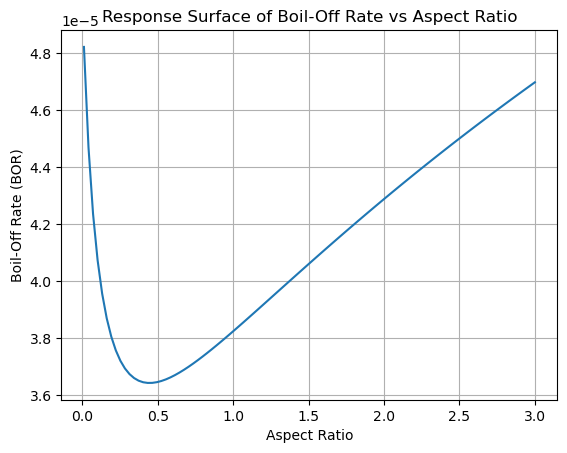

In [6]:
opti.plot_surface_respone(a_array = jax.numpy.linspace(0.01, 3, 100),t_final= 3600 * 2)

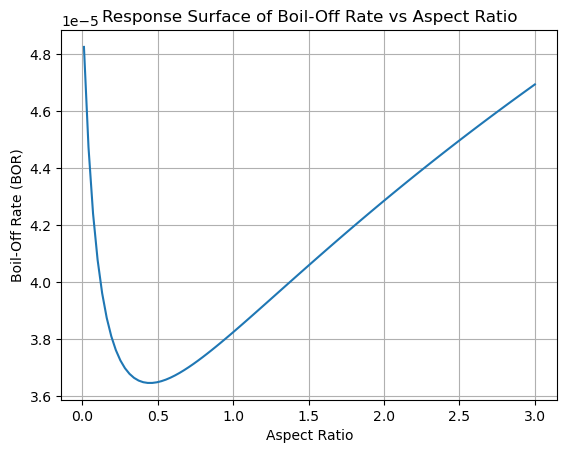

In [7]:
opti.plot_surface_respone(a_array = jax.numpy.linspace(0.01, 3, 100),t_final= 3600 * 720)

In [13]:
optimal_aspect_ratio = opti.optimize(max_iter = 1000, t_final = 2 * 3600, lr = 1e-1, x0 = 0)


Iter 0, Loss 3.873231e-05, Param 0.000000e+00
Iter 1, Loss 3.824429e-05, Param -9.980766e-02
Iter 2, Loss 3.781781e-05, Param -1.991001e-01
Iter 3, Loss 3.745297e-05, Param -2.974399e-01
Iter 4, Loss 3.714909e-05, Param -3.942997e-01
Iter 5, Loss 3.690446e-05, Param -4.890540e-01
Iter 6, Loss 3.671627e-05, Param -5.809752e-01
Iter 7, Loss 3.658039e-05, Param -6.692402e-01
Iter 8, Loss 3.649141e-05, Param -7.529491e-01
Iter 9, Loss 3.644269e-05, Param -8.311609e-01
Iter 10, Loss 3.642663e-05, Param -9.029441e-01
Iter 11, Loss 3.643510e-05, Param -9.674408e-01
Iter 12, Loss 3.645992e-05, Param -1.023929e+00
Iter 13, Loss 3.649348e-05, Param -1.071880e+00
Iter 14, Loss 3.652917e-05, Param -1.110996e+00
Iter 15, Loss 3.656179e-05, Param -1.141215e+00
Iter 16, Loss 3.658761e-05, Param -1.162706e+00
Iter 17, Loss 3.660446e-05, Param -1.175841e+00
Iter 18, Loss 3.661151e-05, Param -1.181157e+00
Iter 19, Loss 3.660905e-05, Param -1.179311e+00
Iter 20, Loss 3.659821e-05, Param -1.171043e+00
Ite

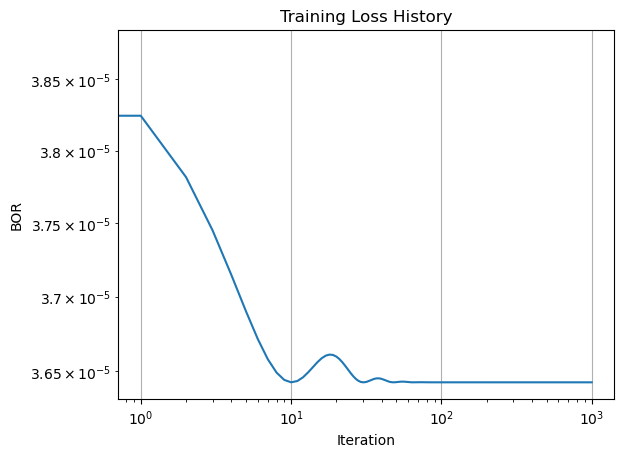

In [14]:
opti.plot_loss_history()

In [15]:
opti.optimal_aspect_ratio

Array(0.50260816, dtype=float64)

In [24]:
optimization = Opti(large_tank, time=720)
opt_aratio = optimization.aspect(verbose=2)
print(opt_aratio)

| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  |
|-------|-------|-------|-------------|----------|----------|----------|
|   1   |   2   |   0   | +3.8851e-05 | 1.00e+00 | 1.69e+00 | 0.00e+00 |
|   2   |   4   |   1   | +3.7205e-05 | 2.00e+00 | 2.00e-01 | 0.00e+00 |
|   3   |   6   |   2   | +3.7205e-05 | 5.47e-01 | 2.00e-01 | 0.00e+00 |
|   4   |   8   |   3   | +3.7205e-05 | 2.73e-01 | 2.00e-01 | 0.00e+00 |
|   5   |  10   |   4   | +3.7205e-05 | 1.37e-01 | 2.00e-01 | 0.00e+00 |
|   6   |  12   |   5   | +3.7205e-05 | 6.83e-02 | 2.00e-01 | 0.00e+00 |
|   7   |  16   |   6   | +3.7205e-05 | 3.42e-02 | 2.00e-01 | 0.00e+00 |
|   8   |  18   |   7   | +3.7205e-05 | 3.42e-03 | 2.00e-01 | 0.00e+00 |
|   9   |  18   |   8   | +3.7205e-05 | 3.42e-04 | 2.00e-01 | 0.00e+00 |
|  10   |  18   |   9   | +3.7205e-05 | 3.42e-05 | 2.00e-01 | 0.00e+00 |
|  11   |  18   |  10   | +3.7205e-05 | 3.42e-06 | 2.00e-01 | 0.00e+00 |
|  12   |  18   |  11   | +3.7205e-05 | 3.42e-07 | 

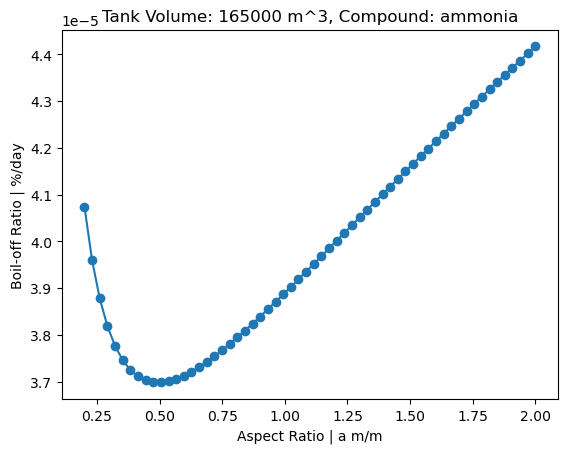

In [17]:
optimization.rs_plot()

#### Visualisation of results

#### Vapour temperature

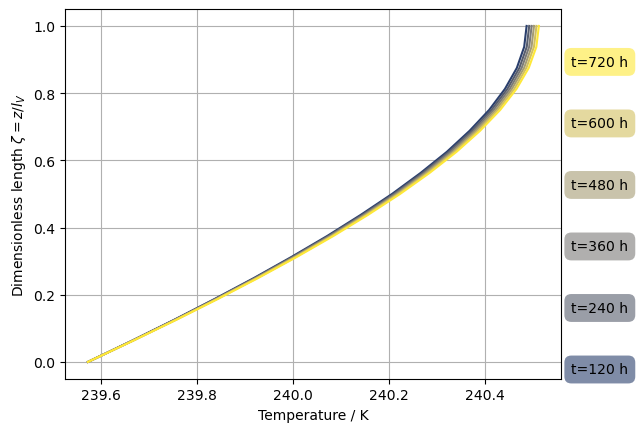

In [8]:
# Visualise the plot
large_tank.plot_tv(t_unit='h')

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

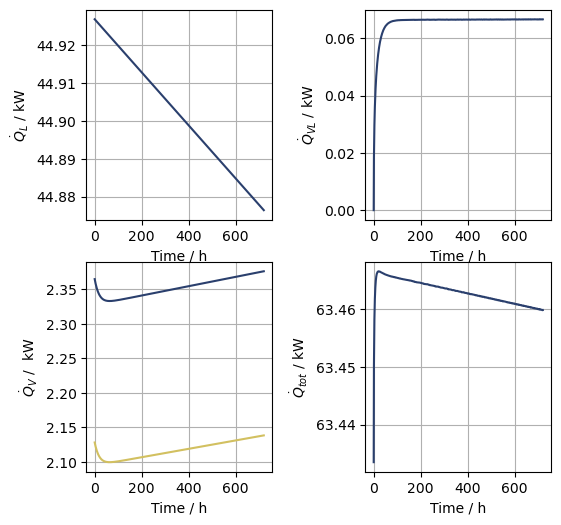

In [8]:
large_tank.plot_Q(unit='kW', t_unit='h')

#### Plot liquid volume

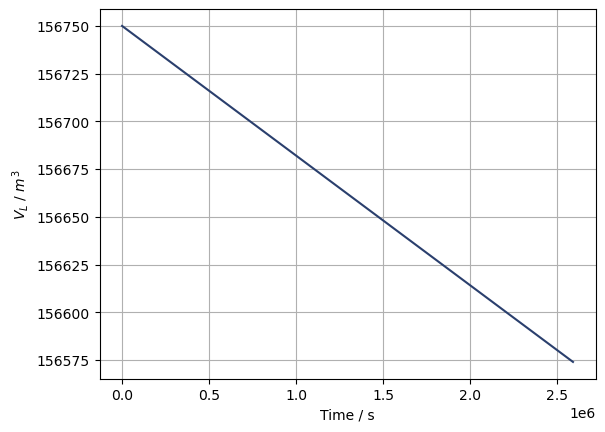

In [9]:
large_tank.plot_V_L()

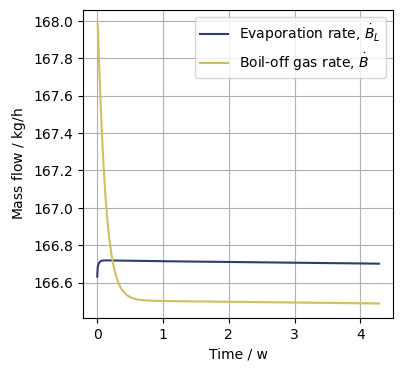

In [10]:
large_tank.plot_BOG(unit='kg/h', t_unit='w')

Optional: CSV data export

If evaporation data is intended to be post-processed in another software, it can be exported readily with the help of the Pandas package.

In [ ]:
# Import pandas 
import pandas as pd

In [ ]:
# Create dataframe from dictionary
df_evap = pd.DataFrame.from_dict(large_tank.data)

# Save file to the current working directory
df_evap.to_csv('methane_165000m3.csv')

# Show the first five columns of the dataframe in console
df_evap.head()

In [ ]:
# BOR = (1 - large_tank.data['V_L'][-1]/large_tank.data['V_L'][0])* (86400/large_tank.data['Time'][-1])
BOR = large_tank.BOR()
print("BOR = %.3e %%" % (100 * BOR))

In [ ]:
large_tank.BOR()

In [ ]:
large_tank.data['Time'][-1]

In [ ]:
large_tank.plot_tv_BOG(t_unit='w')

#### References



F. Huerta, V. Vesovic, A realistic vapour phase heat transfer model for the weathering of LNG stored in large tanks, Energy, 174 (2019) 280-291.